# AGN final project
### Silvia Parente

## Task 1

To classify the dominant excitation mechanisms within the sample, 10,000 narrow emission line galaxies ($z < 0.35$) were extracted from the SDSS database (SQL command 1 in appendix). After calculating the standard logarithmic flux ratios, $\log_{10}([\mathrm{O~III}] \lambda5007 / \mathrm{H}\beta)$ and $\log_{10}([\mathrm{N~II}] \lambda6584 / \mathrm{H}\alpha)$, they were plotted on the BPT diagnostic diagram (Baldwin, Phillips & Terlevich, 1981). 
To separate the sources, the theoretical maximum starburst line derived by Kewley et al. (2001) and the empirical division line derived by Kauffmann et al. (2003). Galaxies below the Kauffmann line were classified as pure star forming galaxies, ionized primarily by hot, young stars in HII regions. Objevts above the Kewley line were classified as AGNs, as their emission requires a harder ionizing continuum produced by an accretion disk. Objects between the two curves were classified as composites, galaxies where both active star formation and a central active nucleus contribute to the line emission.
Since the BPT relies only on line flux ratios, it cannot distinguish between true weakly accreting AGNs and 'retired galaxies'; galaxies that have ceased star formation and have their weak emission lines ionized by a population of hot, low mass evolved stars. 

To resolve this, thr sample was mapped onto the WHAN diagram (Cid Fernandes et al., 2011) that plots the equivalent width of $\mathrm{H}\alpha$ ($W_{\mathrm{H}\alpha}$) against the $[\mathrm{N~II}] / \mathrm{H}\alpha$ ratio. 
The analysis revealed a shift in classification between the two methods: based on the BPT diagnostic 8.85% of the sample was classified as AGNs. But, after applying the WHAN criteria (that requires $W_{\mathrm{H}\alpha} > 6\mathrm{\AA}$ and $\log([\mathrm{N~II}]/\mathrm{H}\alpha) > -0.4$ to confirm a strong AGN) 28.08% of the total sample was classified as true Seyferts. This means that many objects classified as composites (or also star forming) by the BPT curves actually possess the line strengths and ionization states to host an obscured or blended active nucleus. 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


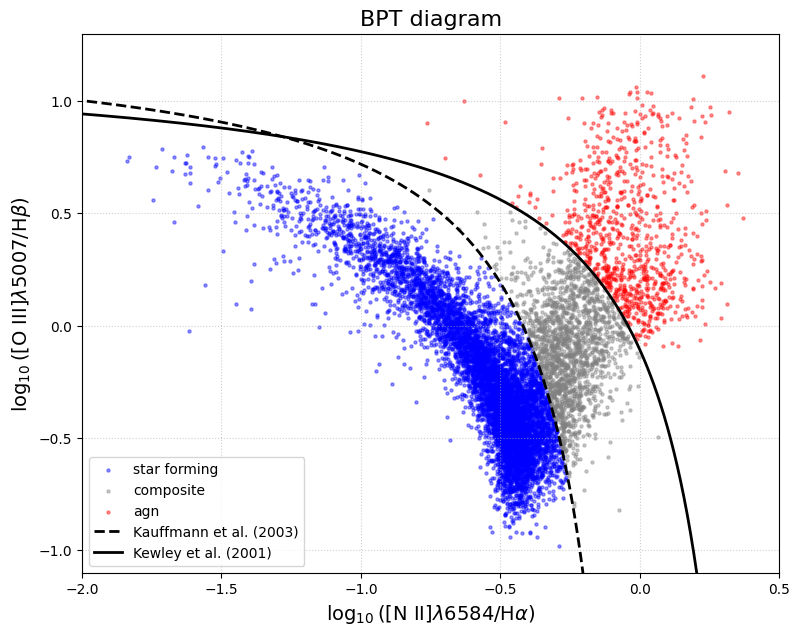

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df1 = pd.read_csv(
    'agnproj_1.csv',           
    comment='#',          
    on_bad_lines='skip',  
)

df1['log_OIII_Hb'] = np.log10(df1['oiii_5007_flux']/df1['h_beta_flux'])
df1['log_NII_Ha'] = np.log10(df1['nii_6584_flux']/df1['h_alpha_flux'])

def kewley(x): return 0.61/(x-0.47)+1.19 # theoretical maximum starburst line
def kauffmann(x): return 0.61/(x-0.05)+1.3 # empirical division between star-forming and AGN

# classify galaxies to color-code:
# star forming below the kauffmann line
cond_sf = (df1['log_NII_Ha'] < 0.05) & (df1['log_OIII_Hb'] < kauffmann(df1['log_NII_Ha']))
# agn above the kewley line 
cond_agn = (df1['log_NII_Ha'] >= 0.47) | (df1['log_OIII_Hb'] > kewley(df1['log_NII_Ha']))
# composites between the two lines
cond_comp = (~cond_sf) & (~cond_agn)


plt.figure(figsize=(9, 7))
plt.scatter(df1.loc[cond_sf, 'log_NII_Ha'], df1.loc[cond_sf, 'log_OIII_Hb'], c='blue', s=5, alpha=0.4, label='star forming')
plt.scatter(df1.loc[cond_comp, 'log_NII_Ha'], df1.loc[cond_comp, 'log_OIII_Hb'], c='grey', s=5, alpha=0.4, label='composite')
plt.scatter(df1.loc[cond_agn, 'log_NII_Ha'], df1.loc[cond_agn, 'log_OIII_Hb'], c='red', s=5, alpha=0.4, label='agn')

x_kew = np.linspace(-2.5, 0.46, 500)
x_kau = np.linspace(-2.5, 0.04, 500)

plt.plot(x_kau, kauffmann(x_kau), 'k--', lw=2, label='Kauffmann et al. (2003)')
plt.plot(x_kew, kewley(x_kew), 'k-', lw=2, label='Kewley et al. (2001)')
plt.xlim(-2.0, 0.5)
plt.ylim(-1.1, 1.3)
plt.xlabel(r'$\log_{10}([\mathrm{N~II}] \lambda6584 / \mathrm{H}\alpha)$', fontsize=14)
plt.ylabel(r'$\log_{10}([\mathrm{O~III}] \lambda5007 / \mathrm{H}\beta)$', fontsize=14)
plt.title('BPT diagram', fontsize=16)
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


total objects analyzed: 10000
BPT Diagram, total AGN: 885 (8.85%)
WHAN Diagram, strong AGN (seyferts): 2808 (28.08%)


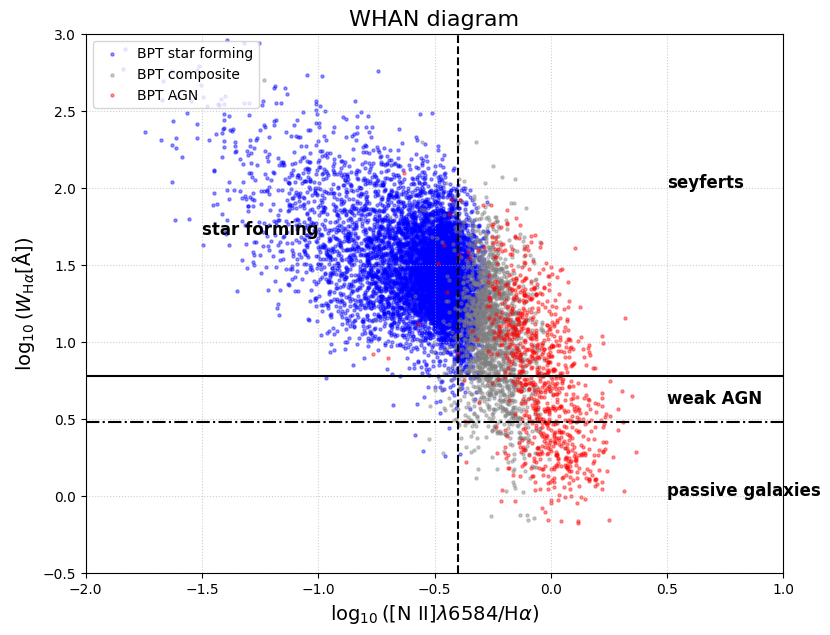

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df1['W_Ha_abs'] = df1['h_alpha_eqw'].abs()

# select positive absolute values 
df_whan = df1[df1['W_Ha_abs'] > 0].copy()
df_whan['log_W_Ha'] = np.log10(df_whan['W_Ha_abs'])

# BPT conditions 
cond_sf_bpt = (df_whan['log_NII_Ha'] < 0.05) & (df_whan['log_OIII_Hb'] < kauffmann(df_whan['log_NII_Ha']))
cond_agn_bpt = (df_whan['log_NII_Ha'] >= 0.47) | (df_whan['log_OIII_Hb'] > kewley(df_whan['log_NII_Ha']))
cond_comp_bpt = (~cond_sf_bpt) & (~cond_agn_bpt)

# WHAN classifications (Cid Fernandes et al. (2011))
cond_sAGN_whan = (df_whan['log_NII_Ha'] > -0.4) & (df_whan['W_Ha_abs'] > 6)

total_objects = len(df_whan)

# BPT agn percentage
num_agn_bpt = cond_agn_bpt.sum()
perc_agn_bpt = (num_agn_bpt / total_objects) * 100

# WHAN strong agn (seyfert) percentage
num_sAGN_whan = cond_sAGN_whan.sum()
perc_sAGN_whan = (num_sAGN_whan / total_objects) * 100

print(f"total objects analyzed: {total_objects}")
print(f"BPT Diagram, total AGN: {num_agn_bpt} ({perc_agn_bpt:.2f}%)")
print(f"WHAN Diagram, strong AGN (seyferts): {num_sAGN_whan} ({perc_sAGN_whan:.2f}%)")


plt.figure(figsize=(9, 7))
plt.scatter(df_whan.loc[cond_sf_bpt, 'log_NII_Ha'], df_whan.loc[cond_sf_bpt, 'log_W_Ha'], 
            c='blue', s=5, alpha=0.4, label='BPT star forming')
plt.scatter(df_whan.loc[cond_comp_bpt, 'log_NII_Ha'], df_whan.loc[cond_comp_bpt, 'log_W_Ha'], 
            c='grey', s=5, alpha=0.4, label='BPT composite')
plt.scatter(df_whan.loc[cond_agn_bpt, 'log_NII_Ha'], df_whan.loc[cond_agn_bpt, 'log_W_Ha'], 
            c='red', s=5, alpha=0.4, label='BPT AGN')

# WHAN lines
# vertical line for strong/weak agn vs star forming
plt.axvline(x=-0.4, color='k', linestyle='--', lw=1.5)
# horizontal line for seyferts vs weak agn
plt.axhline(y=np.log10(6), color='k', linestyle='-', lw=1.5)
# horizontal line for weak agn vs retired galaxies
plt.axhline(y=np.log10(3), color='k', linestyle='-.', lw=1.5)


plt.text(0.5, np.log10(100), 'seyferts', fontsize=12, fontweight='bold')
plt.text(0.5, np.log10(4), 'weak AGN', fontsize=12, fontweight='bold')
plt.text(0.5, np.log10(1), 'passive galaxies', fontsize=12, fontweight='bold')
plt.text(-1.5, np.log10(50), 'star forming', fontsize=12, fontweight='bold')
plt.xlim(-2.0, 1.0)
plt.ylim(-0.5, 3.0) 
plt.xlabel(r'$\log_{10}([\mathrm{N~II}] \lambda6584 / \mathrm{H}\alpha)$', fontsize=14)
plt.ylabel(r'$\log_{10}(W_{\mathrm{H}\alpha} [\mathrm{\AA}])$', fontsize=14)
plt.title('WHAN diagram', fontsize=16)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Task 2

To determine the mid infrared properties of the optical sample, the SDSS dataset was cross matched with the AllWISE catalog using a matching tolerance of 3 arcseconds. The cross match was performed on the SDSS SQL server using the 'wise_xmatch' catalog (SQL command 2 in appendix).

Applied the optical BPT diagnpstic criteria (Kewley et al. 2001) to the sample; 8.85% (885 objects) of the galaxies were classified as optical AGNs. When mapping these objects into the WISE color color diagram (w1-w2 and w2-w3), the mid infrared active galactic nucleus selection wedge defined by Mateos et al. (2012, 2013) was applied. With these criteria, 0.93% (93 objects) of the total sample were classified as mid infrared AGNs. 
The overlap shows a small intersection: 0.09% (9 objects) of the total sample were confirmed as AGNs by both the optical BPT diagnostic and the WISE MIR color wedge. 

The plottedresults illustrate a discrepancy; the BPT diagram identifies a larger percentage of AGNs because it relies on narrow emission line ratios while the WISE color wedge relies on identifying the power law continuum of a hot, dusty torus heated by the accretion disk. 

total objects cross matched in SDSS and WISE: 10000
objects defined as AGN by SDSS (BPT): 885 (8.85%)
objects defined as AGN by WISE (wedge): 93 (0.93%)
objects defined as AGN by both: 9 (0.09%)


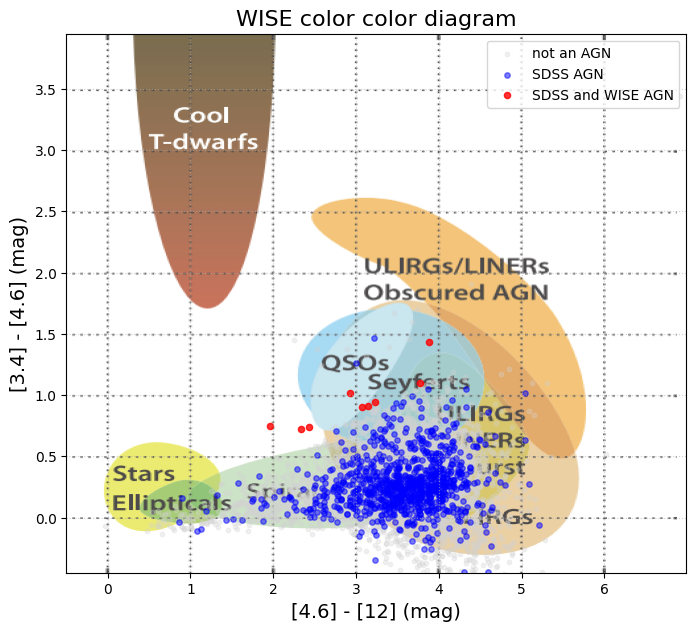

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df2 = pd.read_csv('agnproj_2.csv',comment='#')
total_sdss_objects = len(df2) 

def kewley2001(x): return 0.61 / (x - 0.47) + 1.19
# Kewley et al. (2001) theoretical division line

cond_sdss_agn = (df1['log_NII_Ha'] >= 0.47) | (df1['log_OIII_Hb'] > kewley2001(df1['log_NII_Ha']))
df2['is_sdss_agn'] = cond_sdss_agn

x = df2['w2_w3'] # [4.6] - [12]
y = df2['w1_w2'] # [3.4] - [4.6]

# Mateos et al. wedge criteria
cond_top = y < (0.315 * x + 0.297)
cond_bottom = y > (0.315 * x - 0.110)
cond_left = y > (-3.172 * x + 0.436)

# WISE AGN if falls inside all three boundaries
df2['is_wise_agn'] = cond_top & cond_bottom & cond_left


num_sdss_wise_match = len(df2.dropna(subset=['w1mpro', 'w2mpro', 'w3mpro']))
num_sdss_agn = df2['is_sdss_agn'].sum()
num_wise_agn = df2['is_wise_agn'].sum()
num_both_agn = (df2['is_sdss_agn'] & df2['is_wise_agn']).sum()

# stats
print(f"total objects cross matched in SDSS and WISE: {num_sdss_wise_match}")
print(f"objects defined as AGN by SDSS (BPT): {num_sdss_agn} ({(num_sdss_agn/num_sdss_wise_match)*100:.2f}%)")
print(f"objects defined as AGN by WISE (wedge): {num_wise_agn} ({(num_wise_agn/num_sdss_wise_match)*100:.2f}%)")
print(f"objects defined as AGN by both: {num_both_agn} ({(num_both_agn/num_sdss_wise_match)*100:.2f}%)")


plt.figure(figsize=(8, 7))
img = plt.imread('image.png')
plt.imshow(img, extent=[-0.87, 6.87, -0.45, 3.95], aspect='auto', alpha=0.8)
plt.scatter(x[~df2['is_sdss_agn'] & ~df2['is_wise_agn']], y[~df2['is_sdss_agn'] & ~df2['is_wise_agn']], c='lightgrey', s=10, alpha=0.3, label='not an AGN')
plt.scatter(x[df2['is_sdss_agn'] & ~df2['is_wise_agn']], y[df2['is_sdss_agn'] & ~df2['is_wise_agn']], c='blue', s=15, alpha=0.5, label='SDSS AGN')
plt.scatter(x[df2['is_sdss_agn'] & df2['is_wise_agn']], y[df2['is_sdss_agn'] & df2['is_wise_agn']], c='red', s=20, alpha=0.8, label='SDSS and WISE AGN')
plt.xlim(-0.5, 6.99)
plt.ylim(-0.45, 3.95)
plt.xlabel('[4.6] - [12] (mag)', fontsize=14)
plt.ylabel('[3.4] - [4.6] (mag)', fontsize=14)
plt.title('WISE color color diagram', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Task 3

The electron density ($n_e$) of the ionized gas was estimated by using the density sensitive [S II] $\lambda6717/\lambda6731$ line-flux ratio (sii_6717_flux, sii_6731_flux, and sigma_forbidden in SQL command 1). Plotting $n_e$ across the BPT diagram shows how the star forming sequence exhibits lower electron densities and instead the right wing objects (seyferts and LINERs) show high gas densities.
The [O III] velocity dispersion ($\sigma$) across the BPT diagram shows stark kinematic differences: the star forming branch is dominated by low velocity dispersions ($\sigma < 100$ km/s) and in the AGN region the velocity dispersion increases (over 150-200 km/s). This kinematic broadening in the NLR is a hint of AGN driven outflows and the deeper gravitational potential well near the central supermassive black hole.

Assuming the [O III] velocity dispersion acts as a substitute for the stellar velocity dispersion ($\sigma_*$), the mass of the central supermassive black hole ($M_{BH}$) was estimated using the $M_{BH}-\sigma$ relation (Tremaine et al. 2002). 
The histograms of the BH mass distribution show that star forming galaxies and composites generally host lower mass black holes, peaking at lower masses while objects classified optically as AGNs peak at higher masses ($\log(M_{BH}/M_\odot) > 8$).

To test if the kinematical properties of the NLR are affected by the central black hole mass, the BPT diagram was divided into three mass slots: $\log M_{BH} < 7.0$, $7.0 < \log M_{BH} < 8.0$, and $\log M_{BH} > 8.0$. In the lowest mass bin, almost all galaxies populate the star forming sequence; as the black hole mass increases the population goes toward seyfert and LINER regions.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


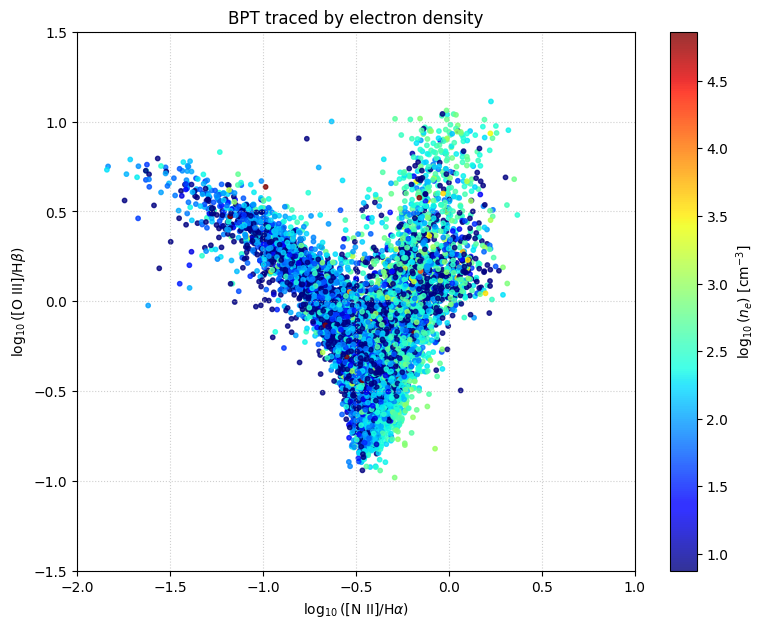

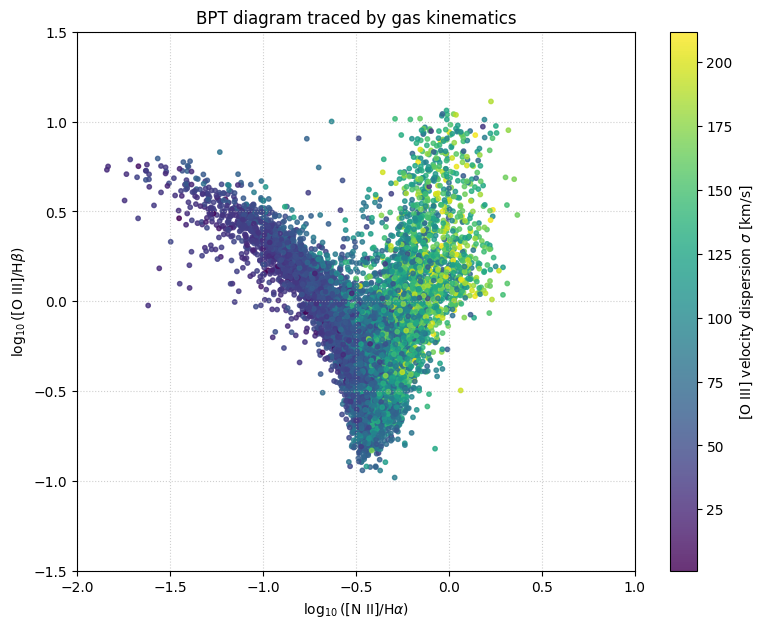

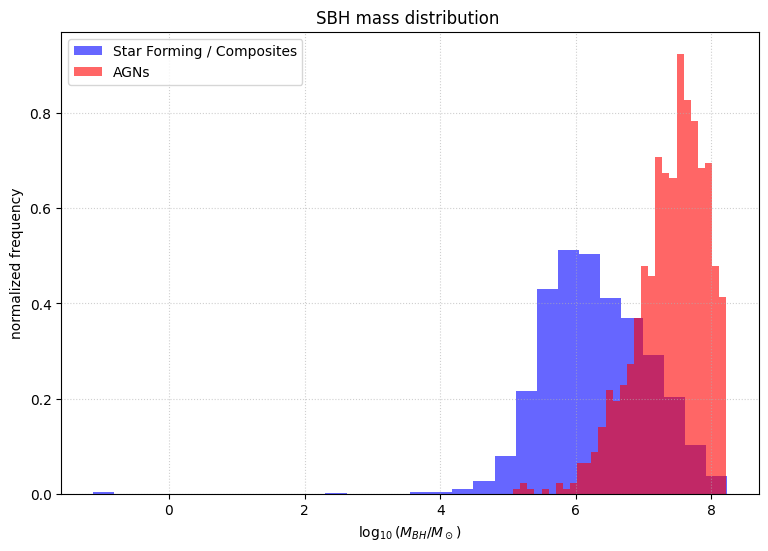

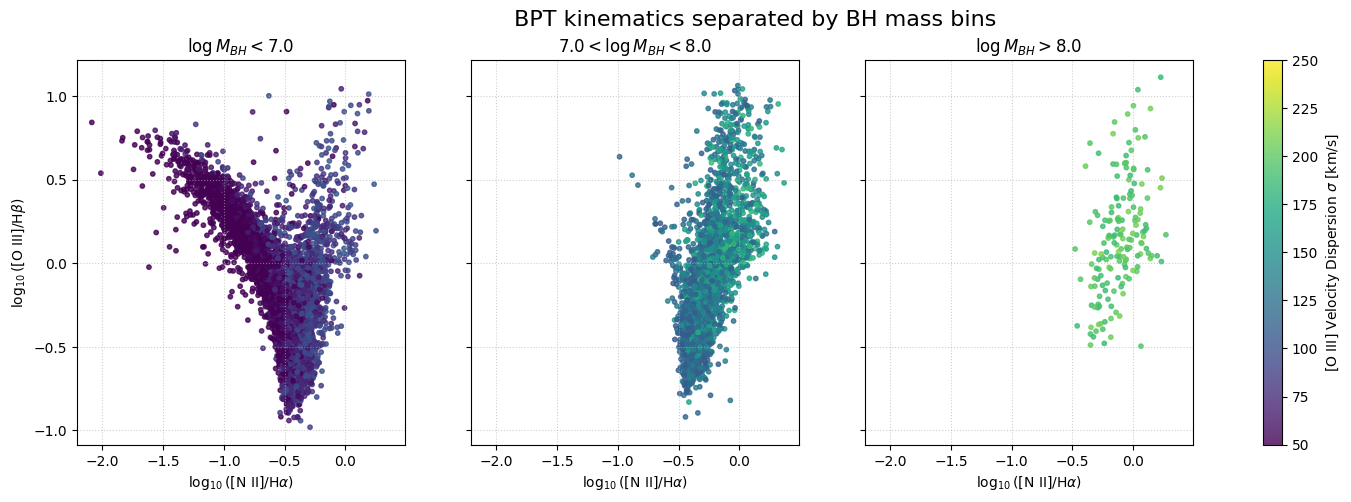

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('agnproj_1.csv', comment='#')
df = df[(df['sii_6717_flux'] > 0) & (df['sii_6731_flux'] > 0) & (df['sigma_forbidden'] > 0)].copy()

df['log_OIII_Hb'] = np.log10(df['oiii_5007_flux'] / df['h_beta_flux'])
df['log_NII_Ha'] = np.log10(df['nii_6584_flux'] / df['h_alpha_flux'])
df['sii_ratio'] = df['sii_6717_flux'] / df['sii_6731_flux']
# clip the ratio to avoid mathematical errors
df['sii_ratio_clipped'] = df['sii_ratio'].clip(0.45, 1.48)
# conversion to electron density (T = 10^4 K)
df['n_e'] = 10000 * (1.49 - df['sii_ratio_clipped']) / (12.8 * df['sii_ratio_clipped'] - 5.6173)
df['log_n_e'] = np.log10(df['n_e'])

# Tremaine et al. 2002 relation
df['log_M_BH'] = 8.13 + 4.02 * np.log10(df['sigma_forbidden'] / 200.0)

def kewley2001(x): return 0.61 / (x - 0.47) + 1.19
cond_agn = (df['log_NII_Ha'] >= 0.47) | (df['log_OIII_Hb'] > kewley2001(df['log_NII_Ha']))

# plot a: BPT traced by electron density
plt.figure(figsize=(9, 7))
sc1 = plt.scatter(df['log_NII_Ha'], df['log_OIII_Hb'], c=df['log_n_e'], cmap='jet', s=10, alpha=0.8)
plt.colorbar(sc1, label=r'$\log_{10}(n_e) \ [\mathrm{cm}^{-3}]$')
plt.xlim(-2.0, 1.0)
plt.ylim(-1.5, 1.5)
plt.xlabel(r'$\log_{10}([\mathrm{N~II}]/\mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}([\mathrm{O~III}]/\mathrm{H}\beta)$')
plt.title('BPT traced by electron density')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# plot b: BPT traced by [O III] velocity dispersion
plt.figure(figsize=(9, 7))
sc2 = plt.scatter(df['log_NII_Ha'], df['log_OIII_Hb'], c=df['sigma_forbidden'], cmap='viridis', s=10, alpha=0.8)
plt.colorbar(sc2, label=r'[O III] velocity dispersion $\sigma$ [km/s]')
plt.xlim(-2.0, 1.0)
plt.ylim(-1.5, 1.5)
plt.xlabel(r'$\log_{10}([\mathrm{N~II}]/\mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}([\mathrm{O~III}]/\mathrm{H}\beta)$')
plt.title('BPT diagram traced by gas kinematics')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# plot c: BH mass distribution 
plt.figure(figsize=(9, 6))
plt.hist(df['log_M_BH'][~cond_agn], bins=30, alpha=0.6, label='Star Forming / Composites', color='blue', density=True)
plt.hist(df['log_M_BH'][cond_agn], bins=30, alpha=0.6, label='AGNs', color='red', density=True)
plt.xlabel(r'$\log_{10}(M_{BH} / M_\odot)$')
plt.ylabel('normalized frequency')
plt.title('SBH mass distribution ')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# plot d: BPT kinematics separated by BH mass bins 
bins = [(0, 7.0), (7.0, 8.0), (8.0, 12)]
bin_labels = [r'$\log M_{BH} < 7.0$', r'$7.0 < \log M_{BH} < 8.0$', r'$\log M_{BH} > 8.0$']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, b, label in zip(axes, bins, bin_labels):
    mask = (df['log_M_BH'] >= b[0]) & (df['log_M_BH'] < b[1])
    sc = ax.scatter(df.loc[mask, 'log_NII_Ha'], df.loc[mask, 'log_OIII_Hb'],
                    c=df.loc[mask, 'sigma_forbidden'], cmap='viridis', s=10, alpha=0.8, vmin=50, vmax=250)
    ax.set_title(label)
    ax.set_xlabel(r'$\log_{10}([\mathrm{N~II}]/\mathrm{H}\alpha)$')
    ax.grid(True, linestyle=':', alpha=0.6)
axes[0].set_ylabel(r'$\log_{10}([\mathrm{O~III}]/\mathrm{H}\beta)$')
fig.colorbar(sc, ax=axes, label=r'[O III] Velocity Dispersion $\sigma$ [km/s]')
plt.suptitle(' BPT kinematics separated by BH mass bins', fontsize=16)
plt.show()

### Appendix
SQL commands. I used the first one on https://skyserver.sdss.org/dr18/SearchTools/sql and the second one on https://skyserver.sdss.org/dr14/en/help/docs/realquery.aspx#wisexmatch .

In [60]:
# SQL command 1
'''
SELECT TOP 10000
    s.specobjid, s.plate, s.mjd, s.fiberid, s.z,
    g.oiii_5007_flux, g.oiii_5007_flux_err,
    g.h_beta_flux, g.h_beta_flux_err,
    g.nii_6584_flux, g.nii_6584_flux_err,
    g.h_alpha_flux, g.h_alpha_flux_err,
    g.sii_6717_flux, g.sii_6731_flux,
    g.oi_6300_flux,
    g.h_alpha_eqw
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
WHERE 
    s.class = 'GALAXY'
    AND s.z < 0.35
    AND s.zWarning = 0
    AND g.sigma_balmer < 212.3
    AND g.sigma_forbidden < 212.3
    AND g.oiii_5007_flux > (5 * g.oiii_5007_flux_err)
    AND g.h_beta_flux > (5 * g.h_beta_flux_err)
    AND g.h_alpha_flux > (5 * g.h_alpha_flux_err)
    AND g.nii_6584_flux > (5 * g.nii_6584_flux_err)
    AND g.h_beta_flux > 0
    AND g.h_alpha_flux > 0
'''


# SQL command 2

''' 
SELECT TOP 10000
    s.ra AS sdss_ra, s.dec AS sdss_dec, w.ra AS wise_ra, w.dec AS wise_dec,
    s.plate, s.mjd, s.fiberid, s.z,
    g.oiii_5007_flux, g.h_beta_flux, g.h_alpha_flux, g.nii_6584_flux,
    w.w1mpro, w.w2mpro, w.w3mpro,
    (w.w1mpro - w.w2mpro) AS w1_w2,
    (w.w2mpro - w.w3mpro) AS w2_w3
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
JOIN wise_xmatch AS x ON s.bestobjid = x.sdss_objid
JOIN wise_allsky AS w ON x.wise_cntr = w.cntr
WHERE 
    s.class = 'GALAXY'
    AND s.z < 0.35
    AND s.zWarning = 0
    AND g.sigma_balmer < 212.3
    AND g.sigma_forbidden < 212.3
    AND g.oiii_5007_flux > (5 * g.oiii_5007_flux_err)
    AND g.h_beta_flux > (5 * g.h_beta_flux_err)
    AND g.h_alpha_flux > (5 * g.h_alpha_flux_err)
    AND g.nii_6584_flux > (5 * g.nii_6584_flux_err)
'''

#tables:
#survey 1
import pandas as pd
pd.options.display.max_rows=10
df1=pd.read_csv('agnproj_1.csv')
print('Survey 1')
print(df1) 
#survey 2
df2=pd.read_csv('agnproj_2.csv')
print('\nSurvey 2')
print(df2) 

Survey 1
                                                                                                                                                                                                                                                                          #Table1
specobjid          plate mjd   fiberid z          oiii_5007_flux oiii_5007_flux_err h_beta_flux h_beta_flux_err nii_6584_flux nii_6584_flux_err h_alpha_flux h_alpha_flux_err sii_6717_flux sii_6731_flux oi_6300_flux h_alpha_eqw sii_6717_flux1 sii_6731_flux1  sigma_forbidden
300682647191971840 267   51608 245     0.01946783 21.52299       0.9800097          15.58486    0.9422239       16.08556      0.7296982         60.90096     1.093727         13.18931      8.636026      2.867806     -21.23338   13.18931       8.636026               30.62449
301741477308950528 268   51633 1       0.06874236 610.9689       6.511196           256.4054    4.280243        114.4482      2.177             878.3365     7.679183    